# Chapter 14
## Neural Networks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from tensorflow import keras
from keras.models import Sequential
from keras.layers import *

np.random.seed(0)

## Dataset

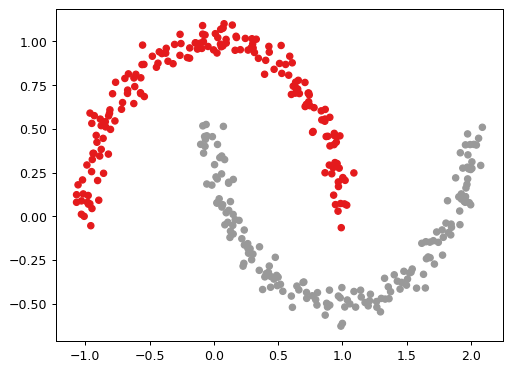

In [13]:
coord, cl = make_moons(500, noise=0.05)
X, Xt, y, yt = train_test_split(coord, cl, test_size=0.3, random_state=0)
cmap_set1 = plt.cm.Set1
_, ax = plt.subplots(dpi=90)
ax.scatter(*np.transpose(X), s=25, c=y, cmap=cmap_set1)
plt.show()

## Neural networks

In [14]:
model = Sequential(
    [
        Input(shape=(2,)),
        Dense(8, activation='relu'),
        Dense(8, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid'),
    ]
)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc', 'Precision'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X, y, epochs=1000, batch_size=32, verbose=0)

In [16]:
model.evaluate(Xt, yt)
predictions = (model.predict(Xt) >= 0.5).astype(int)
test_accuracy = accuracy_score(yt, predictions)
print(f"Accuracy on test set: {test_accuracy}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - Precision: 1.0000 - acc: 1.0000 - loss: 2.3870e-06 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Accuracy on test set: 1.0


### Plotting the decision boundary

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


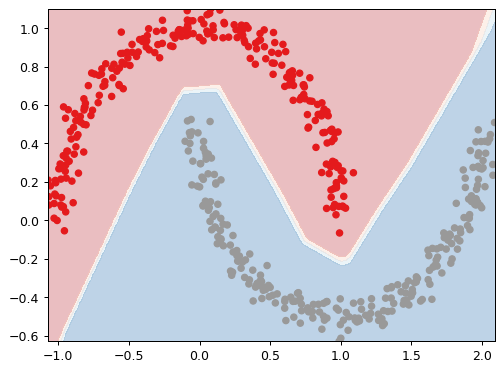

In [17]:
steps = 100
x_range = np.linspace(coord[:,0].min(), coord[:,0].max(), steps)
y_range = np.linspace(coord[:,1].min(), coord[:,1].max(), steps)

xx, yy = np.meshgrid(x_range, y_range)
xy = np.stack([np.ravel(xx), np.ravel(yy)], axis=1)
pp = model.predict(xy)
pp = pp.reshape(yy.shape)

cmap_rb = plt.get_cmap('RdBu')
_, ax = plt.subplots(dpi=90)
ax.contourf(xx, yy, pp, cmap=cmap_rb, alpha=0.3, levels=3)
ax.scatter(*np.transpose(coord), s=25, c=cl, cmap=cmap_set1)
plt.show()

### Convolutional neural networks

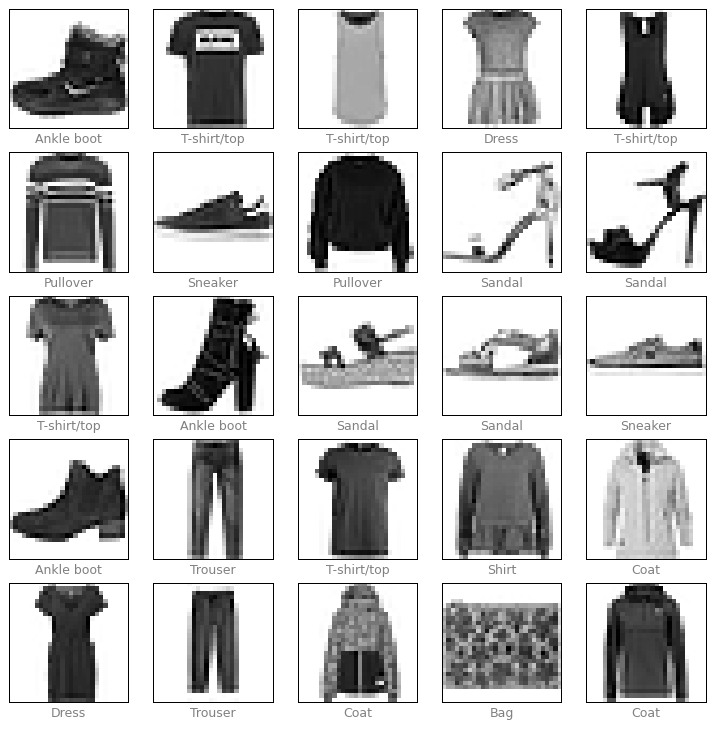

In [25]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = {0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"}

plt.subplots(5, 5, figsize=(10, 10), dpi=90)
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.xlabel(class_names[y_train[i]], c='gray')
plt.show()

In [26]:
num_of_classes = 10
x_train = (x_train / 255).reshape(-1, 28, 28, 1)
x_test = (x_test / 255).reshape(-1, 28, 28, 1)
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

In [27]:
model = Sequential(
    [
        Input(shape=(28, 28, 1)),
        Conv2D(filters=32, kernel_size=(3, 3), strides=1, activation='relu'),
        Conv2D(filters=64, kernel_size=(3, 3), strides=1, activation='relu'),
        MaxPool2D(pool_size=(2, 2)),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_of_classes, activation='softmax')
    ]
)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc',
                                                                                 keras.metrics.Precision(class_id=1),
                                                                                 keras.metrics.Recall(class_id=1)])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │       294,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,090 (1.20 MB)

 Trainable params: 314,090 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(x_train, y_train, batch_size=64, epochs=11, validation_split=0.2)
print("Accuracy: {1}\nPrecision: {2}\nRecall: {3}\nLoss: {0}".format(*model.evaluate(x_test, y_test, verbose=0)))

Epoch 1/11
750/750 ━━━━━━━━━━━━━━━━━━━━ 135s 178ms/step - acc: 0.7679 - loss: 0.6431 - precision_1: 0.9744 - recall: 0.8905 - val_acc: 0.8664 - val_loss: 0.3686 - val_precision_1: 0.9774 - val_recall: 0.9668
Epoch 2/11
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 171ms/step - acc: 0.8559 - loss: 0.4012 - precision_1: 0.9795 - recall: 0.9579 - val_acc: 0.8863 - val_loss: 0.3099 - val_precision_1: 0.9948 - val_recall: 0.9536
Epoch 3/11
750/750 ━━━━━━━━━━━━━━━━━━━━ 130s 173ms/step - acc: 0.8795 - loss: 0.3336 - precision_1: 0.9846 - recall: 0.9633 - val_acc: 0.8892 - val_loss: 0.3019 - val_precision_1: 0.9898 - val_recall: 0.9685
Epoch 4/11
750/750 ━━━━━━━━━━━━━━━━━━━━ 125s 166ms/step - acc: 0.8934 - loss: 0.2941 - precision_1: 0.9869 - recall: 0.9735 - val_acc: 0.8974 - val_loss: 0.2741 - val_precision_1: 0.9891 - val_recall: 0.9768
Epoch 5/11
750/750 ━━━━━━━━━━━━━━━━━━━━ 128s 171ms/step - acc: 0.9032 - loss: 0.2655 - precision_1: 0.9899 - recall: 0.9783 - val_acc: 0.9152 - val_loss: 0.2444 - val_p

### LSTMs

The `air_passengers.feather` file is not found. Let's download it from the GitHub repository.

In [30]:
import os

# Create a 'datasets' directory if it doesn't exist in the current working directory
# This assumes the notebook is running in a location where a 'datasets' subfolder is appropriate.
# If the original intent was a parent directory, this path might need adjustment.
datasets_dir = 'datasets'
if not os.path.exists(datasets_dir):
    os.makedirs(datasets_dir)
    print(f"Created directory: {datasets_dir}")
else:
    print(f"Directory '{datasets_dir}' already exists.")

Created directory: datasets


In [31]:
# Download the file from the raw GitHub URL
# The correct raw URL for the file is needed, not the folder view.
file_url = 'https://raw.githubusercontent.com/gikoluo/ML4D2E/main/datasets/air_passengers.feather'
local_file_path = os.path.join(datasets_dir, 'air_passengers.feather')

!wget -O {local_file_path} {file_url}
print(f"Downloaded {file_url} to {local_file_path}")

--2026-07-28 23:40:26--  https://raw.githubusercontent.com/gikoluo/ML4D2E/main/datasets/air_passengers.feather
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3008 (2.9K) [application/octet-stream]
Saving to: ‘datasets/air_passengers.feather’

datasets/air_passen 100%[===================>]   2.94K  --.-KB/s    in 0s      

2026-07-28 23:40:26 (28.9 MB/s) - ‘datasets/air_passengers.feather’ saved [3008/3008]

Downloaded https://raw.githubusercontent.com/gikoluo/ML4D2E/main/datasets/air_passengers.feather to datasets/air_passengers.feather


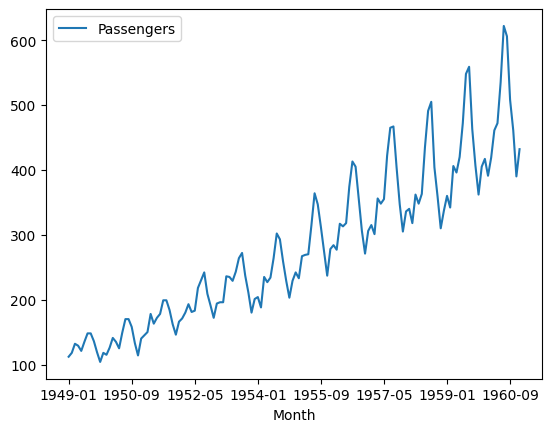

In [35]:
# Now, read the downloaded file
passengers = pd.read_feather(local_file_path).set_index('Month')
passengers.plot()
plt.show()

In [36]:
lookback = 12
sequence = pd.DataFrame({'shift_'+str(s): passengers['Passengers'].shift(s)
                         for s in range(lookback+1)})[lookback:]

y, X = sequence.iloc[:, 0], sequence.iloc[:, 1:]
max_value = np.max(y)
y /= max_value
X /= max_value

shape = list(X.shape)
shape.insert(1, 1)
X = X.values.reshape(shape)

y_train, y_test = y[:-24], y[-24:]
X_train, X_test = X[:-24], X[-24:]

In [37]:
model = Sequential(
    [
        LSTM(units=4, input_shape=(1, lookback)),
        Dense(4, activation='relu'),
        Dense(1)
    ]
)

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4)              │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297 (1.16 KB)

 Trainable params: 297 (1.16 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = model.fit(X_train, y_train, epochs=300, batch_size=8, shuffle=True, verbose=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
RMSE for test set: 42.9


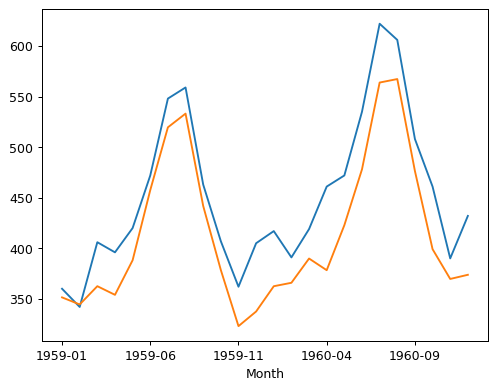

In [39]:
preds = model.predict(X_test) * max_value
reals = y_test * max_value

rmse = np.sqrt(mean_squared_error(y_pred=preds, y_true=reals))
print(f"RMSE for test set: {rmse:0.3}")

_, ax = plt.subplots(dpi=90)
reals.plot()
ax.plot(preds)
plt.show()